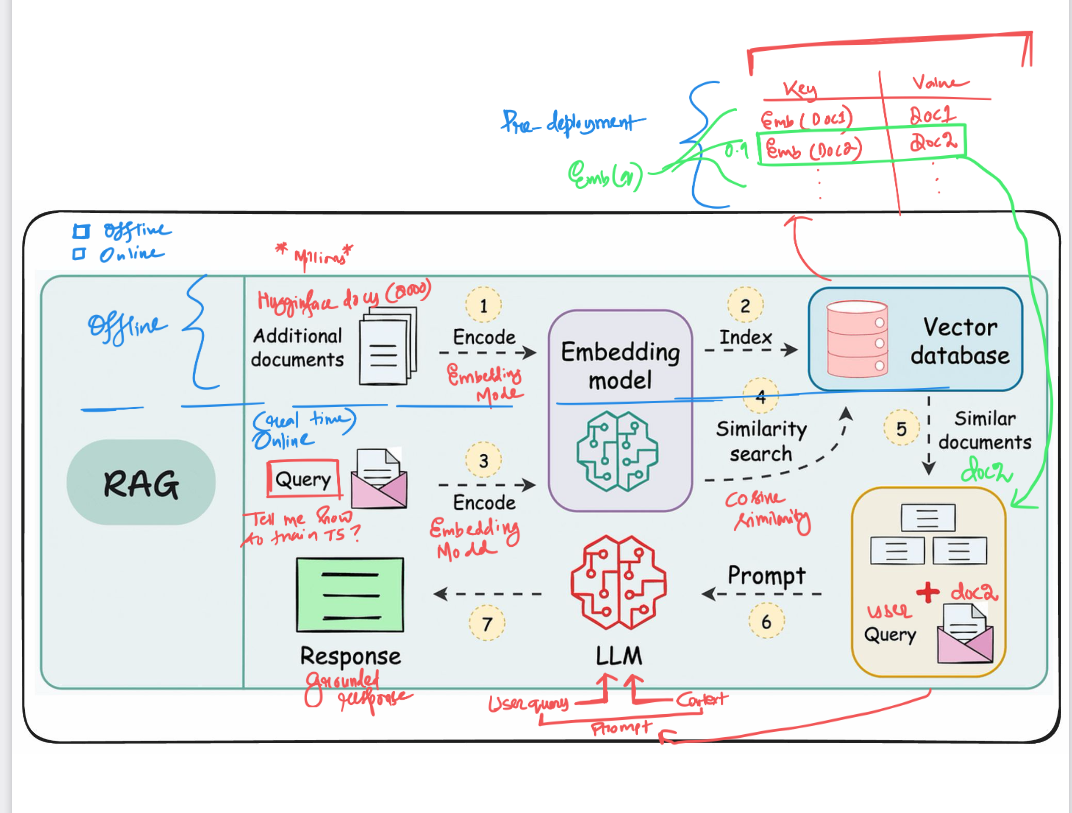

# ANN

## HNSW

- HNSW reduces time for retrieval 
- log(n) instead of O(n) time 

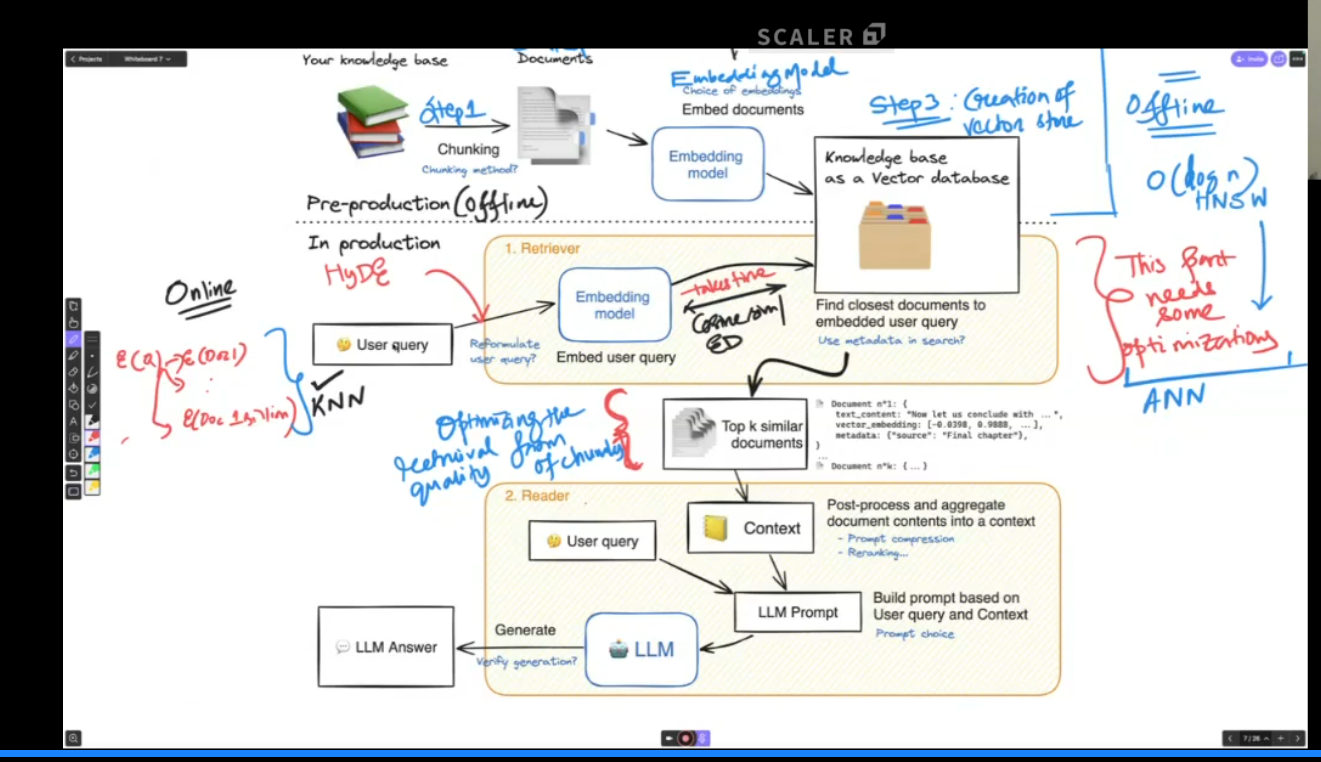

# RAG (Retrieval-Augmented Generation) Interview Cheat Sheet

These are the most commonly asked RAG interview concepts. For each term, know:

- **What it is**
- **Why it is used**
- **When to use it**

---

# 1. RAG (Retrieval-Augmented Generation)

## Definition

Combines an LLM with an external knowledge base to answer questions using retrieved documents.

Instead of relying only on the model's training data, it first retrieves relevant context.

## Pipeline

```text
User Query
      │
      ▼
Embedding Model
      │
      ▼
Vector Database
      │
      ▼
Top-k Retrieved Chunks
      │
      ▼
LLM
      │
      ▼
Final Answer
```

---

# 2. Embeddings

## Definition

Dense numerical vectors representing the semantic meaning of text.

Similar texts have vectors that are close in vector space.

### Example

```text
"Apple phone"

↓

[0.32, -0.71, 0.48, ...]
```

---

# 3. Embedding Model

## Definition

Converts text into vector embeddings.

Used for indexing documents and embedding user queries.

### Examples

- OpenAI `text-embedding-3-small`
- BAAI BGE
- E5
- Sentence Transformers

---

# 4. Vector Database

## Definition

Stores embeddings and performs similarity search.

Returns the most relevant documents for a query.

### Examples

- Milvus
- Pinecone
- Weaviate
- Qdrant
- Chroma
- FAISS

---

# 5. Vector Similarity Search

## Definition

Finds vectors closest to the query vector.

Uses similarity metrics such as:

- Cosine Similarity
- Euclidean Distance
- Dot Product

---

# 6. Cosine Similarity

## Formula

\[
\cos(\theta)=\frac{A\cdot B}{||A||\;||B||}
\]

## Meaning

Measures the angle between two vectors.

Higher cosine similarity means greater semantic similarity.

### Range

| Value | Meaning |
|--------|----------|
| 1 | Identical |
| 0 | Unrelated |
| -1 | Opposite |

---

# 7. Euclidean Distance

## Formula

\[
d=\sqrt{\sum_i(A_i-B_i)^2}
\]

## Meaning

Straight-line distance between vectors.

Smaller distance means greater similarity.

---

# 8. Dot Product

## Formula

\[
A\cdot B=\sum_iA_iB_i
\]

## Meaning

Measures similarity using vector magnitudes and directions.

Common when embeddings are normalized.

---

# 9. ANN (Approximate Nearest Neighbor)

## Definition

Searches for vectors that are approximately nearest instead of exactly nearest.

Much faster than exact search with minimal accuracy loss.

### Why use ANN?

```text
Millions of vectors

↓

Exact search is too slow
```

---

# 10. HNSW (Hierarchical Navigable Small World)

## Definition

State-of-the-art ANN indexing algorithm.

Builds multiple graph layers for fast navigation.

### Advantages

- Extremely fast
- High recall
- Excellent for production RAG

---

# 11. IVF (Inverted File Index)

## Definition

Clusters vectors before searching.

Searches only relevant clusters instead of the whole database.

### Best For

Very large datasets.

---

# 12. IVF-FLAT

## Definition

Uses IVF clustering but performs exact search within selected clusters.

Faster than full search while maintaining good accuracy.

---

# 13. IVF-PQ (Product Quantization)

## Definition

Compresses vectors into smaller representations.

Saves memory at the cost of some accuracy.

---

# 14. Chunking

## Definition

Splits large documents into smaller pieces before embedding.

Improves retrieval quality and fits model context limits.

### Example

```text
100-page PDF

↓

500-word chunks
```

---

# 15. Chunk Size

## Definition

Number of tokens or words in each chunk.

Too small loses context.

Too large mixes unrelated topics.

### Typical Values

**300–1000 tokens**

---

# 16. Chunk Overlap

## Definition

Shared text between consecutive chunks.

Preserves context across chunk boundaries.

### Example

```text
Chunk 1
1-500

Chunk 2
450-950

Overlap = 50 tokens
```

---

# 17. Metadata

## Definition

Additional information stored with each chunk.

Used for filtering and improving retrieval.

### Examples

- Author
- Date
- Source
- Page Number
- Language
- Department

---

# 18. Metadata Filtering

## Definition

Filters documents before similarity search.

Reduces irrelevant retrievals.

### Example

```python
department = "HR"
```

Only HR documents are searched.

---

# 19. Top-k Retrieval

## Definition

Retrieves the **top k** most similar chunks.

Typical values:

**k = 3–10**

---

# 20. Similarity Threshold

## Definition

Minimum similarity score required for a document to be returned.

Prevents low-quality matches.

---

# 21. Semantic Similarity

## Definition

Measures similarity based on meaning rather than exact words.

### Example

```text
Car

↓

Automobile
```

High semantic similarity despite different wording.

---

# 22. Lexical Search

## Definition

Searches using exact keyword matches.

Example:

**BM25**

Best for:

- IDs
- Product names
- Exact terms

---

# 23. BM25

## Definition

Traditional keyword-based ranking algorithm.

Ranks documents using:

- Term Frequency (TF)
- Inverse Document Frequency (IDF)

---

# 24. Hybrid Search

## Definition

Combines vector search and keyword search.

Usually produces better retrieval quality than either alone.

---

# 25. Re-ranking

## Definition

Reorders retrieved documents using a stronger model.

Improves the final context sent to the LLM.

---

# 26. Bi-Encoder

## Definition

Encodes the query and document independently.

Document embeddings are precomputed.

### Pipeline

```text
Query

↓

Encoder

↓

Embedding

↓

Compare

↓

Document Embeddings
```

### Pros

- Very fast
- Highly scalable

### Cons

- Slightly lower accuracy

---

# 27. Cross-Encoder

## Definition

Processes the query and document together.

Produces a relevance score.

### Pipeline

```text
[Query] + [Document]

↓

Single Transformer

↓

Relevance Score
```

### Characteristics

- More accurate
- Much slower

---

# 28. Bi-Encoder vs Cross-Encoder

| **Bi-Encoder** | **Cross-Encoder** |
|----------------|-------------------|
| Encodes separately | Encodes together |
| Fast | Slow |
| Retrieval | Re-ranking |
| Precompute embeddings | No precomputation |
| Highly scalable | More accurate |

---

# 29. HyDE (Hypothetical Document Embeddings)

## Definition

The LLM first generates a hypothetical answer.

That answer is embedded and used for retrieval.

### Pipeline

```text
Question

↓

LLM

↓

Hypothetical Answer

↓

Embedding

↓

Vector Search
```

Useful for vague or short queries.

---

# 30. Query Expansion

## Definition

Expands the user query with related terms.

Improves retrieval coverage.

### Example

```text
Car

↓

Automobile
Vehicle
Sedan
```

---

# 31. Query Rewriting

## Definition

LLM rewrites the user's query into a clearer search query.

Useful for conversational RAG.

---

# 32. Context Window

## Definition

Maximum number of tokens the LLM can process.

Retrieved chunks must fit within this limit.

---

# 33. Context Compression

## Definition

Removes irrelevant information from retrieved documents.

Allows more useful context inside the context window.

---

# 34. Hallucination

## Definition

LLM generates unsupported or incorrect information.

RAG reduces hallucinations by grounding answers using retrieved documents.

---

# 35. Groundedness

## Definition

Every statement in the answer should be supported by retrieved evidence.

Higher groundedness means better factual reliability.

---

# 36. Faithfulness

## Definition

Measures whether the generated answer accurately reflects the retrieved context.

Important evaluation metric for RAG.

---

# 37. Context Precision

## Definition

Fraction of retrieved chunks that are actually relevant.

Higher precision means fewer irrelevant chunks.

---

# 38. Context Recall

## Definition

Fraction of all relevant chunks successfully retrieved.

Higher recall means fewer missing facts.

---

# 39. Mean Reciprocal Rank (MRR)

## Formula

\[
MRR=\frac{1}{N}\sum_{i=1}^{N}\frac{1}{rank_i}
\]

## Measures

How early the first correct result appears.

Higher is better.

---

# 40. Recall@k

## Formula

\[
Recall@k=
\frac{\text{Relevant documents retrieved in Top-k}}
{\text{Total relevant documents}}
\]

## Measures

Retrieval completeness.

---

# 41. Precision@k

## Formula

\[
Precision@k=
\frac{\text{Relevant documents in Top-k}}
{k}
\]

## Measures

Retrieval quality.

---

# 42. Reranker Models

## Examples

- BGE Reranker
- Cohere Rerank
- Cross-Encoder MS MARCO

## Purpose

Improve ranking after the initial retrieval stage.

---

# 43. Dense Retrieval vs Sparse Retrieval

| **Dense Retrieval** | **Sparse Retrieval** |
|---------------------|----------------------|
| Uses embeddings | Uses keywords |
| Semantic search | Exact keyword matching |
| Uses Vector Database | Uses BM25 / TF-IDF |
| Finds synonyms | Misses synonyms |
| Better for natural language | Better for exact terms |
